# Projeto Final — Introdução à Ciência de Dados
## Infrações de Trânsito nas Rodovias do Distrito Federal (2025)

**Integrantes**

- Gabriel Queiroz — gabriel.sabatino@sempreceub.com
- Cauan Bastos — cauan.br@sempreceub.com
- Joao Tarik — joao.tarik@sempreceub.com
- Enzo Machado — enzo.machado@sempreceub.com

**Fonte dos dados:** Portal de Dados Abertos do DF — *Infrações de Trânsito*
🔗 https://www.dados.df.gov.br/dataset/infracoes-transito

**Período analisado:** ano de 2025 (registro completo).

---

### Pergunta central do trabalho

> **Quais são os perfis de risco nas rodovias do Distrito Federal: onde, quando e como as infrações de trânsito se concentram, e o que esses padrões revelam sobre os fatores que mais contribuem para o comportamento infrator?**

A partir dessa pergunta principal, derivamos perguntas menores, cada uma respondida por um ou mais gráficos:

1. **ONDE** — Em quais rodovias do DF as infrações se concentram?
2. **QUANDO** — Existe diferença entre os meses do ano e os dias da semana no volume de infrações?
3. **QUANDO (hora)** — Em quais horários do dia as infrações acontecem mais?
4. **COMO** — Quais tipos de infração são mais cometidos e qual a gravidade predominante?
5. **QUEM** — Que tipos de veículo e de infrator mais aparecem nos registros?
6. **QUANTO** — Como se distribui o valor das multas e ele varia com a gravidade?

## 0. Preparação do ambiente

Importamos as bibliotecas e definimos um padrão visual único para todos os gráficos.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os

# Padrão visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

# Paleta de cores reaproveitada nos gráficos
COR = "#2E5E8C"
PALETA = "viridis"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Ambiente pronto.")

Ambiente pronto.


## 1. Entendimento e descrição do conjunto de dados

Carregamos o conjunto com pandas e exibimos as primeiras linhas.

In [62]:
# O arquivo está na mesma pasta do notebook
df = pd.read_parquet(os.path.join('dados', 'dados_2025.parquet'))
df.head()

,descricao,tipo_infrator,tipo_veiculo,cometimento,grav_tipo,valor_multa,dia_da_semana,hora,mes,rodovia
0,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,grave,195.23,quarta-feira,0,1,df-001
1,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,media,130.16,quarta-feira,0,1,df-459
2,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,media,130.16,quarta-feira,0,1,df-075
3,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,media,130.16,quarta-feira,0,1,df-011
4,transitar em velocidade superior a maxima perm...,condutor,automovel,2025-01-01,media,130.16,quarta-feira,0,1,df-003


### 1.1. Tamanho do conjunto e tipos de coluna

In [63]:
print(f"O conjunto tem {df.shape[0]:,} linhas e {df.shape[1]} colunas.".replace(",", "."))
print()
df.info()

O conjunto tem 788.877 linhas e 10 colunas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788877 entries, 0 to 788876
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   descricao      788877 non-null  string        
 1   tipo_infrator  788877 non-null  string        
 2   tipo_veiculo   788877 non-null  string        
 3   cometimento    788877 non-null  datetime64[ns]
 4   grav_tipo      788877 non-null  category      
 5   valor_multa    788877 non-null  float64       
 6   dia_da_semana  788877 non-null  string        
 7   hora           788877 non-null  Int64         
 8   mes            788877 non-null  int32         
 9   rodovia        788877 non-null  string        
dtypes: Int64(1), category(1), datetime64[ns](1), float64(1), int32(1), string(5)
memory usage: 52.7 MB


### 1.2. O que cada coluna significa

Após o tratamento realizado no notebook `tratamento_dodos.ipynb`, o dataset final contém **10 colunas**:

| Coluna | Significado | Tipo |
|---|---|---|
| `descricao` | Descrição textual da infração cometida | Categórica (texto) |
| `tipo_infrator` | Quem responde pela infração (condutor, proprietário, etc.) | Categórica |
| `tipo_veiculo` | Tipo do veículo envolvido (automóvel, motocicleta, etc.) | Categórica |
| `cometimento` | Data em que a infração foi cometida | Data (`datetime`) |
| `grav_tipo` | Gravidade da infração (leve, média, grave, gravíssima) | Categórica (ordinal) |
| `dia_da_semana` | Dia da semana do cometimento | Categórica |
| `valor_multa` | Valor da multa em reais (R$) | Numérica (`float64`) |
| `hora` | Hora do dia em que a infração ocorreu (0 a 23) | Numérica (`Int64`) |
| `mes` | Mês do cometimento (1 a 12) | Numérica (`int32`) |
| `rodovia` | Código da rodovia extraído do local (ex.: `df-075`, `br-020`) | Categórica |

As colunas numéricas de interesse são `valor_multa`, `hora` e `mes`. A coluna `cometimento` é temporal e as demais são categóricas.

> **Nota:** colunas descartadas no tratamento — `tipo_infracao` (código bruto), `hora_cometimento` (timedelta original) e todas as `auinf_*` (localização com alta taxa de nulos e dados corrompidos) — não estão mais presentes.

### 1.3. Estatísticas básicas das colunas numéricas

O dataset possui três colunas numéricas: `valor_multa` (contínua), `hora` (discreta, 0–23) e `mes` (discreta, 1–12). A seguir, exibimos as estatísticas descritivas de `valor_multa`, a principal variável quantitativa.

In [64]:
stats = df["valor_multa"].agg(["count", "mean", "median", "min", "max", "std"])
moda = df["valor_multa"].mode().iloc[0]

print("Estatísticas de valor_multa (R$):")
print(f"  Contagem (não nulos): {int(stats['count']):,}".replace(",", "."))
print(f"  Média   : R$ {stats['mean']:.2f}")
print(f"  Mediana : R$ {stats['median']:.2f}")
print(f"  Moda    : R$ {moda:.2f}")
print(f"  Mínimo  : R$ {stats['min']:.2f}")
print(f"  Máximo  : R$ {stats['max']:.2f}")
print(f"  Desvio padrão: R$ {stats['std']:.2f}")

Estatísticas de valor_multa (R$):
  Contagem (não nulos): 788.877
  Média   : R$ 167.68
  Mediana : R$ 130.16
  Moda    : R$ 130.16
  Mínimo  : R$ 88.38
  Máximo  : R$ 2934.70
  Desvio padrão: R$ 152.44


> **Leitura inicial:** a média (R\$ 167) é bem maior que a mediana e a moda (R\$ 130,16), indicando uma distribuição **assimétrica à direita**: a maioria das multas é de valor baixo/médio, mas existe uma cauda de multas caras (até R\$ 2.934) que puxa a média para cima.

## 2. Análise e visualização

A seguir, **8 gráficos** que respondem às perguntas derivadas. Cada gráfico vem acompanhado da sua interpretação.

### Gráfico 1 — ONDE: as 10 rodovias com mais infrações

*Pergunta: em quais rodovias do DF as infrações se concentram?*

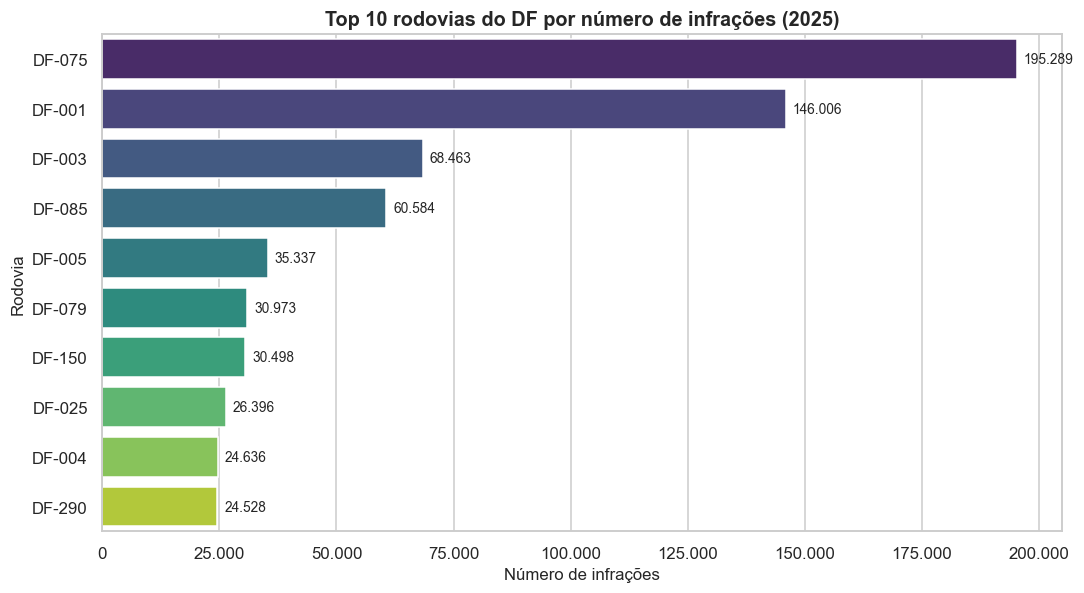

In [65]:
top_rod = (df[df["rodovia"] != "outra/nao identificada"]
           ["rodovia"].value_counts().head(10))

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=top_rod.values, y=[r.upper() for r in top_rod.index],
            hue=[r.upper() for r in top_rod.index], palette=PALETA, legend=False, ax=ax)
ax.set_title("Top 10 rodovias do DF por número de infrações (2025)")
ax.set_xlabel("Número de infrações")
ax.set_ylabel("Rodovia")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
for i, v in enumerate(top_rod.values):
    ax.text(v + 1500, i, f"{v:,}".replace(",", "."), va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretação:** As infrações são **fortemente concentradas em poucas vias**. A **DF-075 (EPNB)** lidera com folga, seguida pela **DF-001 (EPCT, o Anel Viário)** e pela **DF-003 (EPIA)**. Essas três vias sozinhas concentram a maior parte dos registros identificáveis — são corredores de alto fluxo do DF. Isso aponta que a fiscalização (e o risco) está geograficamente concentrada, não espalhada de forma uniforme pelas rodovias.

### Gráfico 2 — QUANDO: volume de infrações por mês

*Pergunta: existe diferença entre os meses do ano no volume de infrações?*

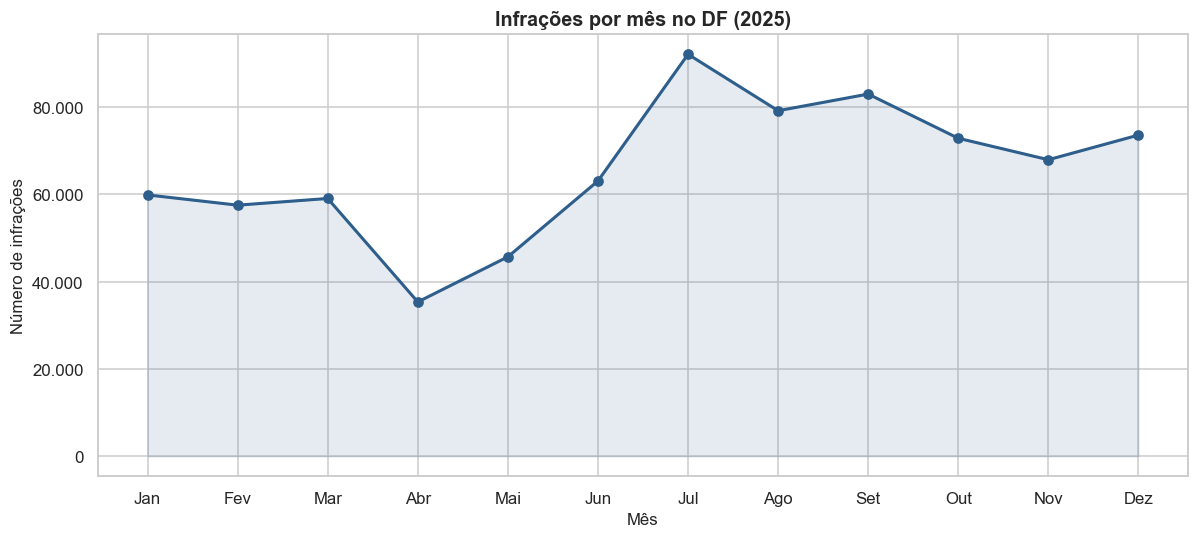

In [66]:
meses_nome = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
              "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
por_mes = df["mes"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(por_mes.index, por_mes.values, marker="o", color=COR, linewidth=2)
ax.fill_between(por_mes.index, por_mes.values, alpha=0.12, color=COR)
ax.set_title("Infrações por mês no DF (2025)")
ax.set_xlabel("Mês")
ax.set_ylabel("Número de infrações")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nome)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** O volume de infrações **varia ao longo do ano**, sem uma tendência única de crescimento ou queda — há meses de pico e meses de vale. Essa oscilação provavelmente reflete a intensidade da fiscalização (campanhas, radares ativos) mais do que uma mudança real de comportamento dos motoristas, já que o número de carros nas ruas não muda tanto mês a mês. É um ponto a tratar com honestidade: **o dado mede infrações *registradas*, que dependem de fiscalização**, e não necessariamente todas as infrações que ocorreram.

### Gráfico 3 — QUANDO: infrações por dia da semana

*Pergunta: os dias úteis e os fins de semana se comportam de forma diferente?*

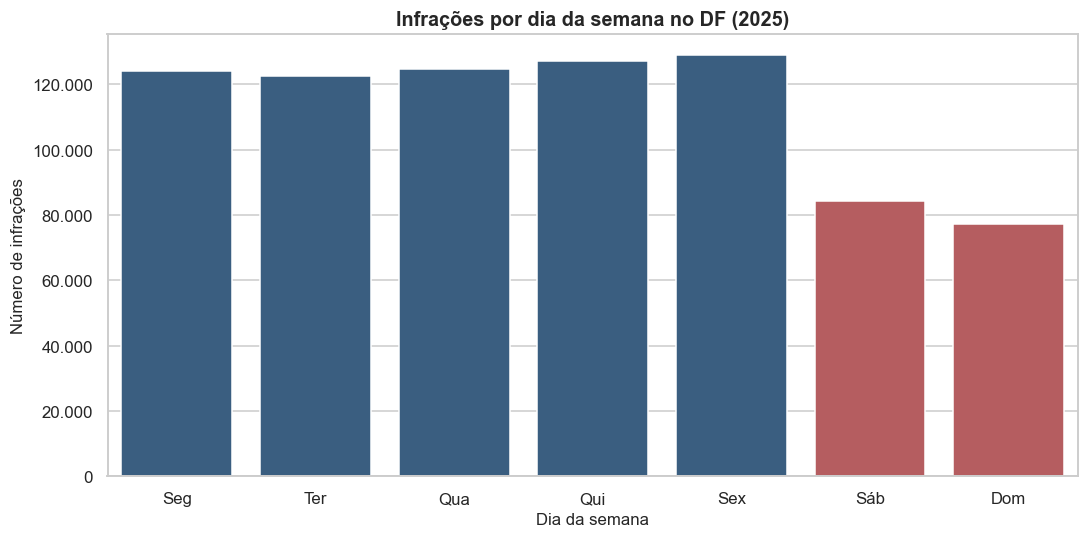

In [67]:
ordem_dias = ["segunda-feira", "terca-feira", "quarta-feira", "quinta-feira",
              "sexta-feira", "sabado", "domingo"]
rotulo_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
por_dia = df["dia_da_semana"].value_counts().reindex(ordem_dias)

cores = [COR]*5 + ["#C44E52"]*2  # destaca fim de semana
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=rotulo_dias, y=por_dia.values, palette=cores, hue=rotulo_dias, legend=False, ax=ax)
ax.set_title("Infrações por dia da semana no DF (2025)")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Número de infrações")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** Os **dias úteis (azul)** concentram bem mais infrações que o **fim de semana (vermelho)**. Sexta-feira é o pico e o domingo é o menor. Isso é coerente com o volume de tráfego: durante a semana há o deslocamento casa-trabalho, com mais carros, mais radares ativos em horário comercial e, portanto, mais autuações. Reforça a ideia de que o **perfil de risco está ligado ao trânsito de rotina (deslocamento pendular)**, não ao lazer de fim de semana.

### Gráfico 4 — QUANDO: distribuição das infrações por hora do dia

*Pergunta: em quais horários as infrações se concentram?*

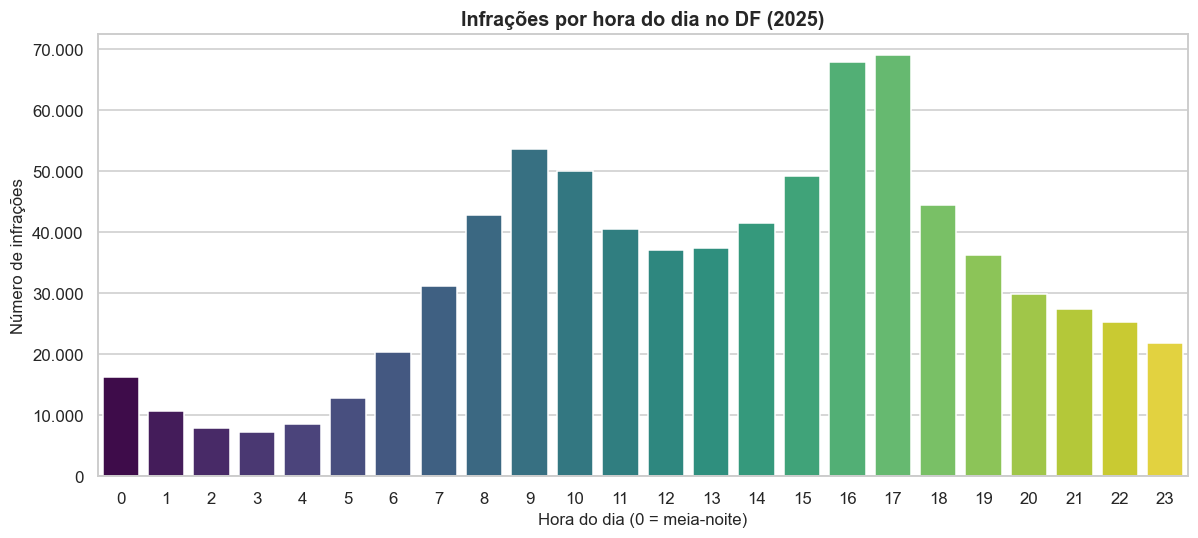

In [68]:
por_hora = df["hora"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=por_hora.index, y=por_hora.values,
            hue=por_hora.index, palette=PALETA, legend=False, ax=ax)
ax.set_title("Infrações por hora do dia no DF (2025)")
ax.set_xlabel("Hora do dia (0 = meia-noite)")
ax.set_ylabel("Número de infrações")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** As infrações se concentram nas **horas de pico do dia**, com elevação ao longo da manhã e da tarde e queda forte na madrugada. Os horários de maior movimento (deslocamento para trabalho/escola e o retorno no fim da tarde) são os de maior número de autuações. Confirma o padrão dos gráficos anteriores: **o risco está atrelado ao trânsito intenso do dia a dia**.

### Gráfico 5 — COMO: todas as infrações cometidas

*Pergunta: quais comportamentos infratores são mais frequentes?*

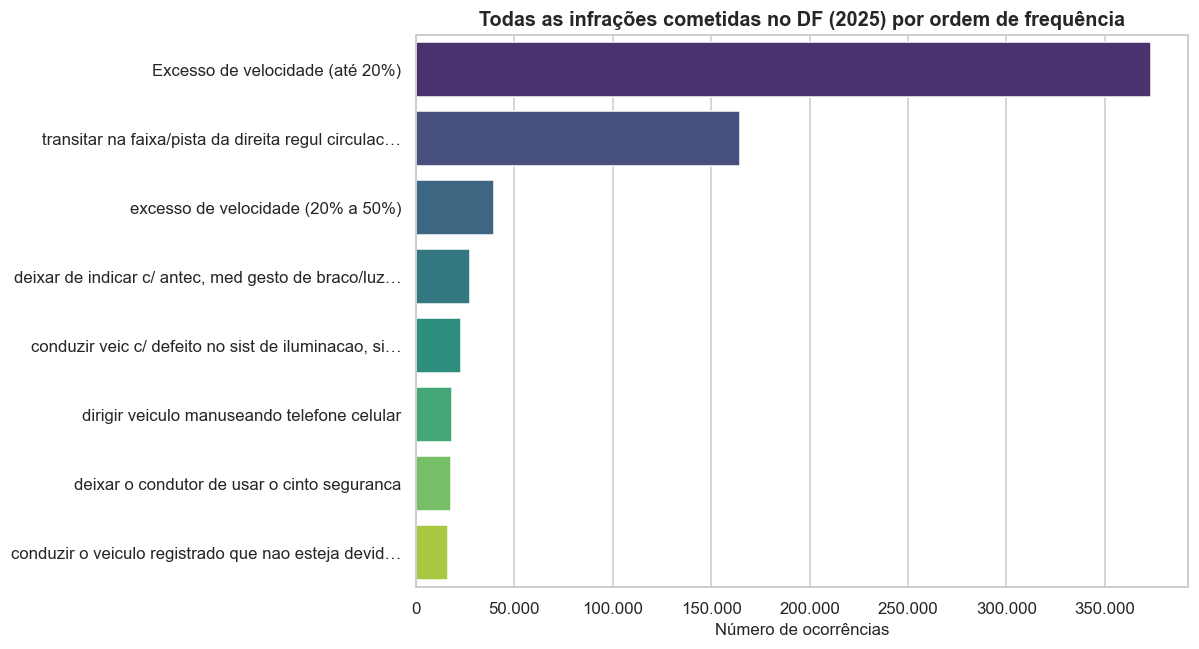

In [69]:
top_inf = df["descricao"].value_counts().head(8)
# encurtar rótulos muito longos
rot = []
for d in top_inf.index:
    if "ate 20%" in d:
        rot.append("Excesso de velocidade (até 20%)")
    elif "mais de 20%" in d:
        rot.append("excesso de velocidade (20% a 50%)")
    else:
        rot.append(d[:50] + "…" if len(d) > 50 else d)

# Ajusta a altura da figura dinamicamente
altura = max(6, len(top_inf) * 0.25)
fig, ax = plt.subplots(figsize=(11, altura))
sns.barplot(x=top_inf.values, y=rot, hue=rot, palette=PALETA, legend=False, ax=ax)

ax.set_title("Todas as infrações cometidas no DF (2025) por ordem de frequência")
ax.set_xlabel("Número de ocorrências")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))

plt.tight_layout()
plt.show()

**Interpretação:** O ranking é **dominado pelo excesso de velocidade** — *"transitar em velocidade superior à máxima permitida em até 20%"* é, isolada, a infração mais comum, muito à frente das demais. Em seguida aparece *"transitar na faixa da direita"* e outras condutas. Ou seja, o comportamento infrator nº 1 nas rodovias do DF é **dirigir acima do limite de velocidade**, o fator clássico associado a acidentes mais graves.

### Gráfico 6 — COMO: distribuição das infrações por gravidade

*Pergunta: as infrações são majoritariamente leves ou graves?*

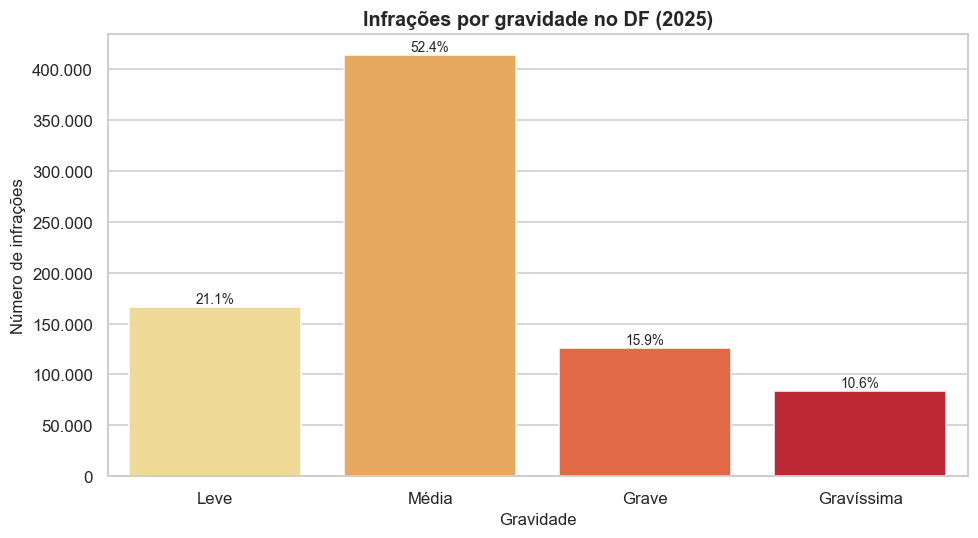

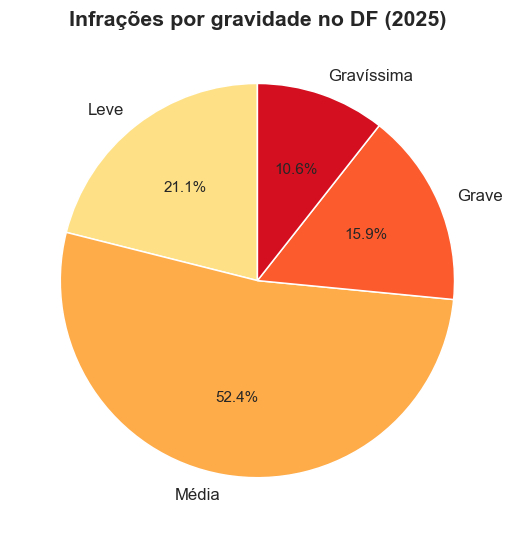

In [70]:
# Barra
por_grav = df["grav_tipo"].value_counts().reindex(['leve', 'media', 'grave', 'gravissima'])
rotulo_grav = ["Leve", "Média", "Grave", "Gravíssima"]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=rotulo_grav, y=por_grav.values,
            hue=rotulo_grav, palette="YlOrRd", legend=False, ax=ax)
ax.set_title("Infrações por gravidade no DF (2025)")
ax.set_xlabel("Gravidade")
ax.set_ylabel("Número de infrações")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y):,}".replace(",", ".")))
total = por_grav.sum()
for i, v in enumerate(por_grav.values):
    ax.text(i, v + 4000, f"{v/total*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# Pizza
fig, ax = plt.subplots(figsize=(5, 5))
cores = sns.color_palette("YlOrRd", len(rotulo_grav))

ax.pie(
    por_grav.values, 
    labels=rotulo_grav, 
    colors=cores, 
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title("Infrações por gravidade no DF (2025)", fontsize=14)
plt.tight_layout()
plt.show()

**Interpretação:** A maior parte das infrações é de gravidade **média**, seguida de **leve**. As infrações **graves** e **gravíssimas** somam uma fatia menor, mas longe de desprezível (juntas, cerca de um quarto dos registros). Como a infração mais comum é "velocidade até 20% acima" (classificada como média), faz sentido que essa categoria domine. O fato de existir um volume relevante de gravíssimas é um alerta de segurança.

### Gráfico 7 — QUEM: tipos de veículo mais autuados

*Pergunta: que veículos mais aparecem nos registros?*

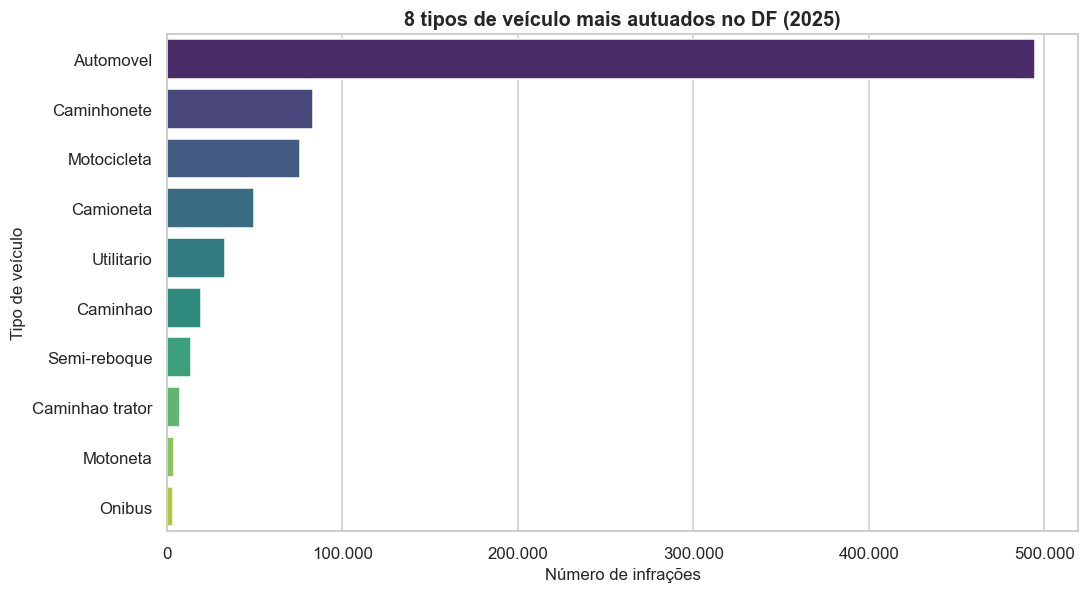

In [71]:
top_veic = df["tipo_veiculo"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=top_veic.values, y=[v.capitalize() for v in top_veic.index],
            hue=[v.capitalize() for v in top_veic.index], palette=PALETA, legend=False, ax=ax)
ax.set_title("8 tipos de veículo mais autuados no DF (2025)")
ax.set_xlabel("Número de infrações")
ax.set_ylabel("Tipo de veículo")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
plt.tight_layout()
plt.show()

**Interpretação:** O **automóvel** domina amplamente as autuações, o que é esperado por ser o veículo mais comum na frota. Logo depois vêm **caminhonete**, **motocicleta** e **camioneta**. É importante a honestidade aqui: este gráfico mostra **volume absoluto**, não **risco por veículo** — para dizer qual *tipo* é mais infrator proporcionalmente, precisaríamos do tamanho da frota de cada categoria, que **não está nestes dados**. Concluímos apenas que o grosso das infrações vem de automóveis.

### Gráfico 8 — QUANTO: distribuição dos valores exatos das multas

*Pergunta: como se distribui, no geral, o valor pago em multas?*

C:\Users\cauan\AppData\Local\Temp\ipykernel_15564\7949463.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"R$ {x:.2f}" for x in valores.index])


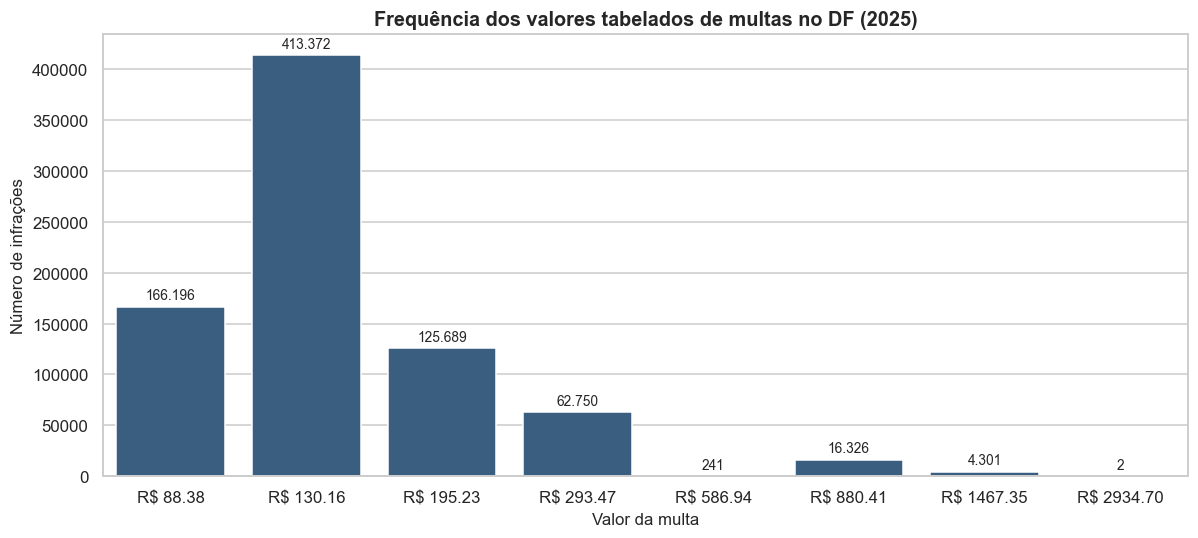

In [72]:
valores = df["valor_multa"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=valores.index, y=valores.values, color=COR, ax=ax)

# Formata os rótulos do eixo X para mostrar como moeda
ax.set_xticklabels([f"R$ {x:.2f}" for x in valores.index])

ax.set_title("Frequência dos valores tabelados de multas no DF (2025)")
ax.set_xlabel("Valor da multa")
ax.set_ylabel("Número de infrações")

# Adiciona o valor exato no topo de cada barra para facilitar a leitura
for i, p in enumerate(ax.patches):
    ax.annotate(f"{int(p.get_height()):,}".replace(",", "."), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretação:** Como os valores das multas são tabelados pelo CTB (R$ 88,38 para leve; R$ 130,16 para média; R$ 195,23 para grave; e R$ 293,47 ou seus múltiplos para gravíssimas), a distribuição não é contínua, mas sim formada por **apenas 8 valores exatos**. Esse gráfico de barras mostra muito mais claramente que a multa de **R$ 130,16 (média)** é a mais comum de longe, representando mais da metade das autuações. Os valores multiplicados (acima de R$ 880) têm baixa incidência, mas são os responsáveis por puxar a média geral (R$ 164) para cima da mediana.

## 3. Conclusões

Retomando a pergunta central — *quais são os perfis de risco nas rodovias do DF: onde, quando e como as infrações se concentram?* — chegamos às seguintes conclusões, cada uma sustentada por evidência mostrada acima.

**Conclusão 1 — O risco é geograficamente concentrado (ONDE).**
As infrações não se distribuem de forma uniforme pelo DF: poucas vias respondem pela maior parte dos registros, com destaque para **DF-075 (EPNB), DF-001 (EPCT) e DF-003 (EPIA)** (Gráfico 1). São corredores de alto fluxo. Para reduzir infrações, faz sentido priorizar fiscalização e engenharia de tráfego nessas vias.

**Conclusão 2 — O risco segue o trânsito de rotina (QUANDO).**
As infrações concentram-se em **dias úteis** (pico na sexta, vale no domingo — Gráfico 3) e nas **horas de movimento do dia** (Gráfico 4). O padrão acompanha o deslocamento pendular casa-trabalho, não o lazer de fim de semana. Já a variação **mês a mês** (Gráfico 2) é mais instável e provavelmente reflete a intensidade da fiscalização.

**Conclusão 3 — O comportamento infrator nº 1 é o excesso de velocidade, predominantemente de gravidade média (COMO).**
A infração isolada mais comum é *transitar acima do limite em até 20%* (Gráfico 5), e a gravidade predominante é **média** (Gráfico 6). O valor típico pago é baixo (~R\$ 130), com uma cauda de multas caras (Gráfico 8). Ou seja: muitas infrações de velocidade "leve", poucas gravíssimas — mas estas últimas, embora minoria, são o ponto de maior preocupação de segurança.

---

### Limitações e honestidade sobre os dados

- **Não medimos risco *por veículo*** (Gráfico 7 mostra volume, não taxa): faltam dados de tamanho da frota para dizer qual *tipo* infringe proporcionalmente mais.
- **Os dados de geolocalização (lat/long) estão corrompidos** e foram descartados; a análise espacial ficou limitada ao código da rodovia.
- **O conjunto registra infrações *fiscalizadas*, não todas as cometidas.** Variações temporais podem refletir radares ativos/campanhas, não apenas o comportamento dos motoristas. Por isso, falamos em "infrações registradas" e evitamos afirmar mudanças de comportamento que o dado não comprova.